# A05 - Pipeline

|                |                  |
:----------------|------------------|
| **Nombre**     | Omar Mendoza     |
| **Fecha**      | 17/09/2026       |
| **Expediente** | 757806           |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [2]:
# Cargar el excel, la hoja mtcars es la que trae los datos

df = pd.read_excel("Motor Trend Car Road Tests.xlsx", sheet_name="mtcars")

df.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


## EDA

In [3]:
print(df.shape)
df.dtypes

(32, 12)


model     object
mpg      float64
cyl        int64
disp     float64
hp         int64
drat     float64
wt       float64
qsec     float64
vs         int64
am         int64
gear       int64
carb       int64
dtype: object

In [4]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
mpg,32.0,20.09,6.03,10.40,15.42,19.20,22.80,33.90
cyl,32.0,6.19,1.79,4.00,4.00,6.00,8.00,8.00
disp,32.0,230.72,123.94,71.10,120.82,196.30,326.00,472.00
hp,32.0,146.69,68.56,52.00,96.50,123.00,180.00,335.00
drat,32.0,3.60,0.53,2.76,3.08,3.70,3.92,4.93
wt,32.0,3.22,0.98,1.51,2.58,3.32,3.61,5.42
qsec,32.0,17.85,1.79,14.50,16.89,17.71,18.90,22.90
vs,32.0,0.44,0.50,0.00,0.00,0.00,1.00,1.00
am,32.0,0.41,0.50,0.00,0.00,0.00,1.00,1.00
gear,32.0,3.69,0.74,3.00,3.00,4.00,4.00,5.00


In [5]:
# Faltantes y duplicados

print("Nulos:", df.isna().sum().sum())
print("Duplicados:", df.duplicated().sum())

Nulos: 0
Duplicados: 0


In [6]:
# Cuantos valores distintos tiene cada columna para ver cual es categorica

df.nunique()

model    32
mpg      25
cyl       3
disp     27
hp       22
drat     22
wt       29
qsec     30
vs        2
am        2
gear      3
carb      6
dtype: int64

Son 32 autos y 12 columnas, sin nulos ni duplicados

mpg es la que queremos predecir (millas por galon). model es el nombre del carro asi que no sirve como factor

Aunque todas vienen como numero no todas son numericas de verdad, cyl gear y carb solo toman 3 o 6 valores asi que son categorias, y vs y am son 0 o 1 o sea booleanas. Las numericas de verdad son disp hp drat wt y qsec

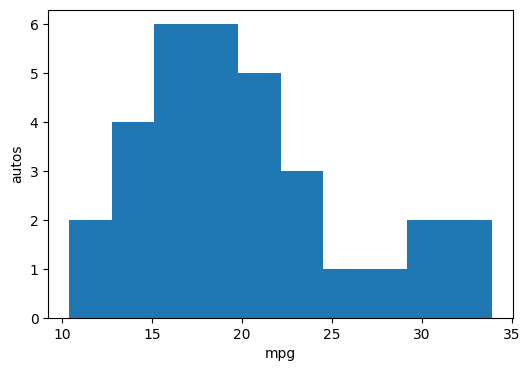

In [7]:
# Como se reparte mpg

plt.figure(figsize=(6, 4))
plt.hist(df["mpg"], bins=10)
plt.xlabel("mpg")
plt.ylabel("autos")
plt.show()

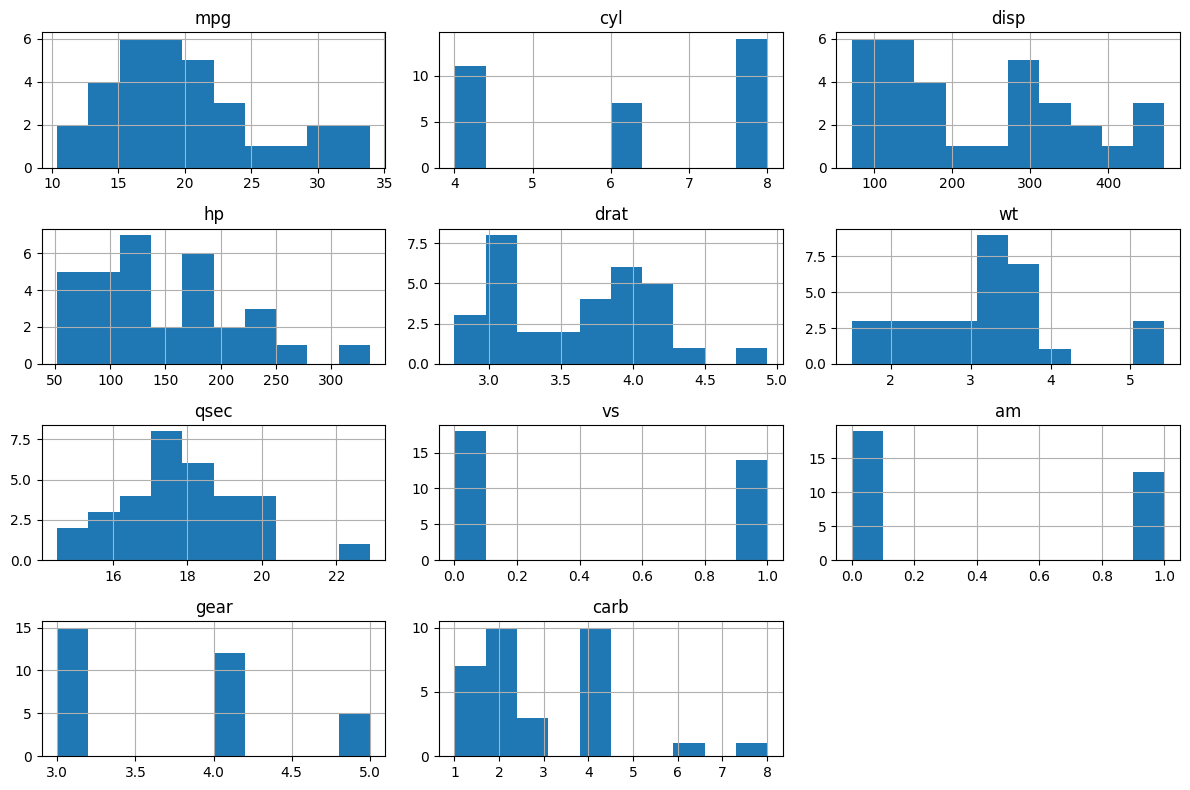

In [8]:
df.drop(columns="model").hist(figsize=(12, 8), bins=10)
plt.tight_layout()
plt.show()

In [9]:
# Que tanto se relaciona cada columna con mpg

df.drop(columns="model").corr()["mpg"].drop("mpg").sort_values().round(3)

wt     -0.868
cyl    -0.852
disp   -0.848
hp     -0.776
carb   -0.551
qsec    0.419
gear    0.480
am      0.600
vs      0.664
drat    0.681
Name: mpg, dtype: float64

wt y cyl son las que mas bajan el mpg (-0.87 y -0.85), y drat y vs las que mas lo suben. Tiene sentido, entre mas pesado y mas cilindros mas gasta

La hipotesis es que el peso y la potencia son lo que mas explica el rendimiento

## Separar columnas

In [10]:
# Se quita model porque es el nombre

df = df.drop(columns="model")

df.columns

Index(['mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear',
       'carb'],
      dtype='object')

In [11]:
target_col = ["mpg"]

numerical_cols = ["disp", "hp", "drat", "wt", "qsec"]
categorical_cols = ["cyl", "gear", "carb"]
boolean_cols = ["vs", "am"]

X = df.drop(columns=target_col)
y = df[target_col]

print(X.shape, y.shape)

(32, 10) (32, 1)


## Preprocesador

In [12]:
# Numericas se escalan, categoricas a one hot, booleanas pasan tal cual

numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols),
        ("bool", "passthrough", boolean_cols),
    ],
    remainder="drop",
)

## Pipeline

In [13]:
model = LinearRegression()

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ]
)

pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [14]:
# Como quedaron las columnas despues del preprocesador

pipeline["preprocessor"].get_feature_names_out()

array(['num__disp', 'num__hp', 'num__drat', 'num__wt', 'num__qsec',
       'cat__cyl_4', 'cat__cyl_6', 'cat__cyl_8', 'cat__gear_3',
       'cat__gear_4', 'cat__gear_5', 'cat__carb_1', 'cat__carb_2',
       'cat__carb_3', 'cat__carb_4', 'cat__carb_6', 'cat__carb_8',
       'bool__vs', 'bool__am'], dtype=object)

In [15]:
# Coeficientes y R2 del modelo que quedo adentro del pipeline

print("B0:", pipeline["model"].intercept_)
print("R2:", pipeline.score(X, y))

pd.Series(pipeline["model"].coef_[0], index=pipeline["preprocessor"].get_feature_names_out()).round(3)

B0: [20.67682621]
R2: 0.8930749320864843


num__disp      4.336
num__hp       -4.758
num__drat      0.622
num__wt       -4.362
num__qsec      0.647
cat__cyl_4     0.995
cat__cyl_6    -1.654
cat__cyl_8     0.659
cat__gear_3   -1.214
cat__gear_4   -0.100
cat__gear_5    1.314
cat__carb_1   -2.473
cat__carb_2   -3.453
cat__carb_3    0.526
cat__carb_4   -1.382
cat__carb_6    2.004
cat__carb_8    4.777
bool__vs       1.931
bool__am       1.212
dtype: float64

Las 5 numericas quedaron escaladas, cyl gear y carb se abrieron en una columna por cada valor (12 en total) y vs y am pasaron igual. En total 19 columnas

El R2 sale de 0.89, alto pero es con los mismos datos con los que se entreno y son nada mas 32 autos

## Y predicha y residuos

In [16]:
y_pred = pipeline.predict(X).ravel()
y_real = y["mpg"].values

residuos = y_real - y_pred

resultados = pd.DataFrame({"mpg": y_real, "mpg predicha": y_pred, "residuo": residuos}).round(2)
resultados.head(10)

,mpg,mpg predicha,residuo
0,21.0,21.38,-0.38
1,21.0,20.43,0.57
2,22.8,26.31,-3.51
3,21.4,20.81,0.59
4,18.7,17.43,1.27
5,18.1,18.79,-0.69
6,14.3,13.61,0.69
7,24.4,24.06,0.34
8,22.8,23.04,-0.24
9,19.2,18.44,0.76


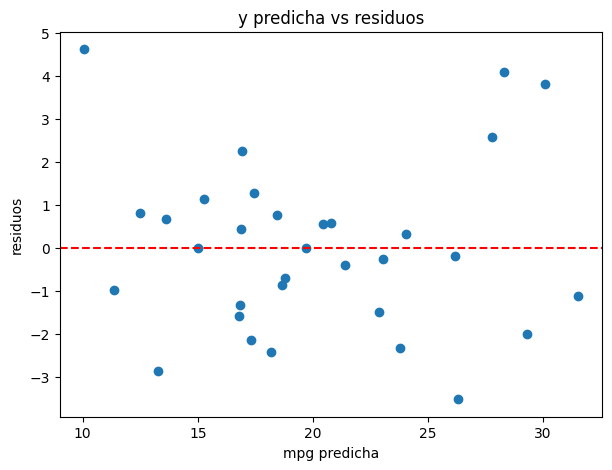

In [17]:
# Grafica de la y predicha contra los residuos

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuos)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("mpg predicha")
plt.ylabel("residuos")
plt.title("y predicha vs residuos")
plt.show()

Los residuos quedan repartidos alrededor del cero sin ninguna forma clara, no se ve curva ni embudo. Los mas grandes andan por 3 o 4 mpg y son pocos

Como son solo 32 autos no hay muchos puntos para ver patrones, pero con lo que hay el modelo lineal se ve razonable